In [6]:
%pip install catboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd

train = pd.read_csv("../dataset/final_cleaned_crop_yield_train.csv")
test = pd.read_csv("../dataset/final_cleaned_crop_yield_test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (12545, 9)
Test shape: (3131, 9)


,Year,State,Crop,Season,Area,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,2009,Madhya Pradesh,Sweet potato,Whole Year,3497.00,904.1,544902.54,594.49,6.020000
1,2001,Nagaland,Jute,Kharif,300.00,1532.0,30639.00,78.00,0.986667
2,2004,Jharkhand,Sugarcane,Whole Year,542.97,1149.2,58825.37,114.02,25.710000
3,2011,Jammu and Kashmir,Potato,Kharif,1015.00,887.6,170032.80,334.95,7.661250
4,2015,Odisha,Potato,Winter,5626.00,1210.1,888401.66,1856.58,9.889630


In [2]:
X_train = train.drop("Yield", axis=1)
y_train = train["Yield"]

X_test = test.drop("Yield", axis=1)
y_test = test["Yield"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nFeatures:")
print(X_train.columns.tolist())

X_train: (12545, 8)
y_train: (12545,)
X_test: (3131, 8)
y_test: (3131,)

Features:
['Year', 'State', 'Crop', 'Season', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide']


In [3]:
categorical_features = ["State", "Crop", "Season"]

print("Categorical features:", categorical_features)
print("Categorical indices:",
      [X_train.columns.get_loc(col) for col in categorical_features])

Categorical features: ['State', 'Crop', 'Season']
Categorical indices: [1, 2, 3]


In [4]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

0:	learn: 947.0334123	total: 241ms	remaining: 4m
100:	learn: 159.7478485	total: 7.29s	remaining: 1m 4s
200:	learn: 122.2762578	total: 13.9s	remaining: 55.2s
300:	learn: 100.3122414	total: 19.7s	remaining: 45.6s
400:	learn: 88.2806454	total: 27.7s	remaining: 41.4s
500:	learn: 78.9158674	total: 34.5s	remaining: 34.4s
600:	learn: 69.5644648	total: 40.8s	remaining: 27.1s
700:	learn: 60.7163048	total: 47.5s	remaining: 20.2s
800:	learn: 54.1080579	total: 55.5s	remaining: 13.8s
900:	learn: 49.2355871	total: 1m 2s	remaining: 6.88s
999:	learn: 45.4335351	total: 1m 7s	remaining: 0us


CatBoostRegressor(depth=8, iterations=1000, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [5]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[4.28952894e+00 3.00442030e+00 1.98083829e+00 1.66217858e+00
 4.16213982e+00 8.41380760e+03 5.55812801e-01 1.07429601e+00
 3.36631387e-01 6.74868273e-01]


In [6]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("------------------")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)

Model Performance
------------------
MAE  : 18.463819367309284
RMSE : 180.8993799366859
R²   : 0.9626055172169102


In [7]:
importance = model.get_feature_importance()

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
}).sort_values("Importance", ascending=False)

print(feature_importance)

           Feature  Importance
2             Crop   62.672501
6       Fertilizer   22.399768
3           Season    5.067022
7        Pesticide    2.998504
1            State    2.672566
5  Annual_Rainfall    2.438870
0             Year    0.928787
4             Area    0.821982


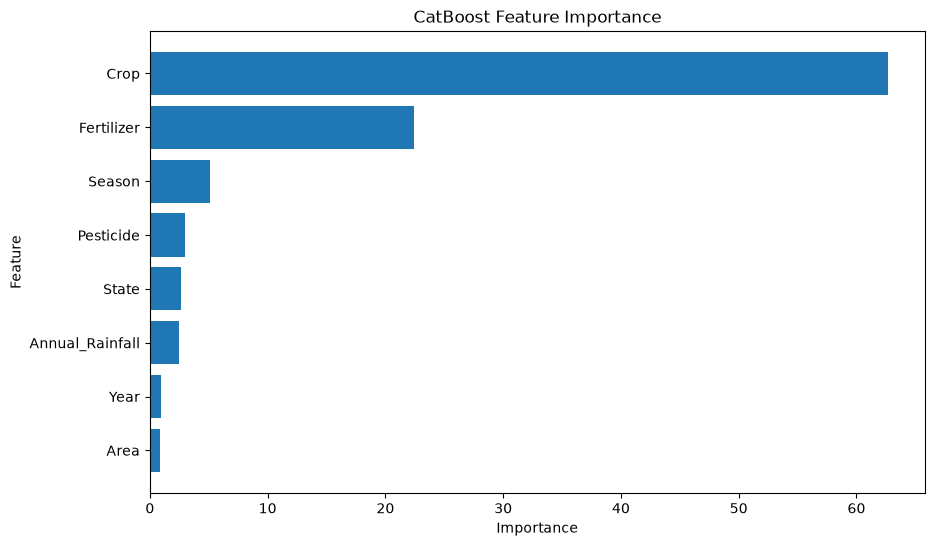

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("CatBoost Feature Importance")
plt.gca().invert_yaxis()

plt.show()

In [9]:
comparison = pd.DataFrame({
    "Actual_Yield": y_test.values,
    "Predicted_Yield": y_pred
})

print(comparison.head(20))

    Actual_Yield  Predicted_Yield
0       3.694545         4.289529
1       0.578333         3.004420
2       1.895238         1.980838
3       0.207143         1.662179
4       0.095000         4.162140
5    9984.488333      8413.807599
6       1.595000         0.555813
7       1.255833         1.074296
8       1.006923         0.336631
9       0.721667         0.674868
10      1.022500         1.145601
11      0.399130        -0.490055
12      0.448750         0.825250
13      9.471000         5.301447
14      0.335556        -0.643664
15      1.226667         2.294809
16      0.893333         0.358622
17      0.483333         5.921588
18      0.448333         0.584385
19      1.658410        -1.139003


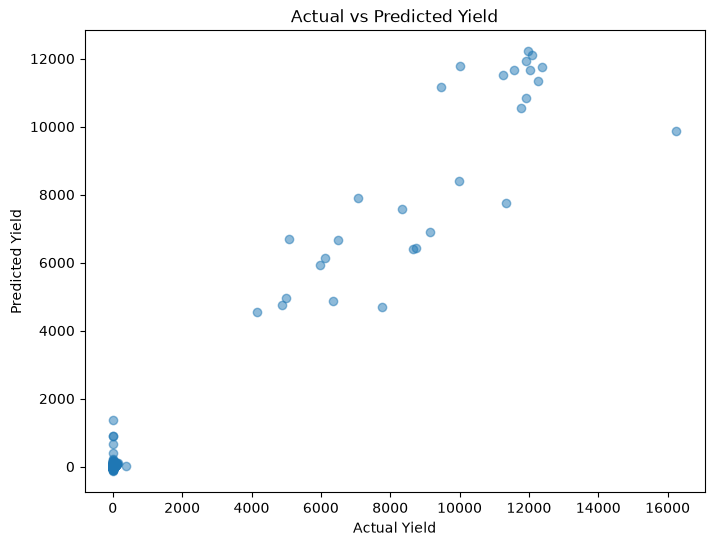

In [10]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")

plt.show()

In [11]:
results = test[["Crop", "Yield"]].copy()
results["Predicted_Yield"] = y_pred

crop_performance = results.groupby("Crop").apply(
    lambda x: pd.Series({
        "MAE": mean_absolute_error(x["Yield"], x["Predicted_Yield"]),
        "RMSE": np.sqrt(mean_squared_error(
            x["Yield"], x["Predicted_Yield"]
        )),
        "R2": r2_score(x["Yield"], x["Predicted_Yield"])
    })
).reset_index()

print(crop_performance.sort_values("R2", ascending=False).to_string(index=False))

                 Crop         MAE        RMSE            R2
              Coconut 1211.802372 1833.554618      0.612657
            Sugarcane   16.099401   20.910575      0.459843
                Maize    1.661804    2.366948      0.038316
                Onion    8.277202   38.275156      0.022567
               Banana   12.669376   15.751132     -0.095949
Peas & beans (Pulses)    1.488629    2.220357     -0.469138
               Garlic    4.470242    5.303913     -0.575471
                Bajra    1.486285    4.330636     -0.600997
             Turmeric    3.476824    4.409920     -0.923354
               Barley    0.996725    1.333071     -1.071793
               Ginger    5.976485   11.033473     -1.622792
         Dry chillies    3.312378    4.373462     -1.806308
         Sweet potato    5.899425    9.156675     -2.335454
         Cotton(lint)    1.487323    2.263195     -2.841887
       other oilseeds   13.747748   18.277870     -6.797426
               Potato    7.613019   19.2

In [13]:
import numpy as np

y_train_log = np.log1p(y_train)

# Log-transformed CatBoost

In [14]:
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Transform the target
y_train_log = np.log1p(y_train)

# Create model
log_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

# Train the model
log_model.fit(
    X_train,
    y_train_log,
    cat_features=categorical_features
)

# Predict
y_pred_log = log_model.predict(X_test)

# Convert predictions back to original Yield scale
y_pred_original = np.expm1(y_pred_log)

# Yield cannot be negative
y_pred_original = np.maximum(y_pred_original, 0)

# Evaluate
mae_log = mean_absolute_error(y_test, y_pred_original)
rmse_log = np.sqrt(
    mean_squared_error(y_test, y_pred_original)
)
r2_log = r2_score(y_test, y_pred_original)

print("Log-Transformed CatBoost Performance")
print("--------------------------------------")
print("MAE  :", mae_log)
print("RMSE :", rmse_log)
print("R²   :", r2_log)

0:	learn: 1.1862785	total: 45.3ms	remaining: 45.2s
100:	learn: 0.3234325	total: 5.89s	remaining: 52.4s
200:	learn: 0.2718711	total: 13.3s	remaining: 52.8s
300:	learn: 0.2419294	total: 21s	remaining: 48.8s
400:	learn: 0.2215355	total: 28.8s	remaining: 43s
500:	learn: 0.2059510	total: 36.5s	remaining: 36.3s
600:	learn: 0.1934312	total: 44.2s	remaining: 29.4s
700:	learn: 0.1835622	total: 52.1s	remaining: 22.2s
800:	learn: 0.1749299	total: 59.9s	remaining: 14.9s
900:	learn: 0.1675492	total: 1m 7s	remaining: 7.44s
999:	learn: 0.1606991	total: 1m 15s	remaining: 0us
Log-Transformed CatBoost Performance
--------------------------------------
MAE  : 20.370593805351135
RMSE : 339.12857819515744
R²   : 0.8685797913329085


In [15]:
print("MODEL COMPARISON")
print("================")

print("\nOriginal CatBoost")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)

print("\nLog-Transformed CatBoost")
print("MAE  :", mae_log)
print("RMSE :", rmse_log)
print("R²   :", r2_log)

MODEL COMPARISON

Original CatBoost
MAE  : 18.463819367309284
RMSE : 180.8993799366859
R²   : 0.9626055172169102

Log-Transformed CatBoost
MAE  : 20.370593805351135
RMSE : 339.12857819515744
R²   : 0.8685797913329085


## 5-Fold Cross-Validation

In [16]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor
import numpy as np

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

mae_scores = []
rmse_scores = []
r2_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    model_cv = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=8,
        loss_function="RMSE",
        random_seed=42,
        verbose=False
    )

    model_cv.fit(
        X_tr,
        y_tr,
        cat_features=categorical_features
    )

    pred = model_cv.predict(X_val)

    mae = mean_absolute_error(y_val, pred)
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    r2 = r2_score(y_val, pred)

    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    print(f"Fold {fold}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    print()

Fold 1
MAE  : 24.9394
RMSE : 207.5089
R²   : 0.9597

Fold 2
MAE  : 20.6411
RMSE : 314.7758
R²   : 0.9187

Fold 3
MAE  : 17.6756
RMSE : 152.6475
R²   : 0.9705

Fold 4
MAE  : 19.5415
RMSE : 188.9278
R²   : 0.9638

Fold 5
MAE  : 18.4153
RMSE : 163.2291
R²   : 0.9668



In [17]:
print("5-FOLD CROSS-VALIDATION RESULTS")
print("================================")

print(f"Average MAE  : {np.mean(mae_scores):.4f}")
print(f"Average RMSE : {np.mean(rmse_scores):.4f}")
print(f"Average R²   : {np.mean(r2_scores):.4f}")

print("\nStandard Deviation")
print(f"MAE  Std : {np.std(mae_scores):.4f}")
print(f"RMSE Std : {np.std(rmse_scores):.4f}")
print(f"R²   Std : {np.std(r2_scores):.4f}")

5-FOLD CROSS-VALIDATION RESULTS
Average MAE  : 20.2426
Average RMSE : 205.4178
Average R²   : 0.9559

Standard Deviation
MAE  Std : 2.5550
RMSE Std : 57.9656
R²   Std : 0.0189


### Hyperparameter tuning


In [18]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

configs = [
    {
        "name": "Baseline",
        "iterations": 1000,
        "learning_rate": 0.05,
        "depth": 8
    },
    {
        "name": "Model 2",
        "iterations": 1500,
        "learning_rate": 0.03,
        "depth": 8
    },
    {
        "name": "Model 3",
        "iterations": 1000,
        "learning_rate": 0.05,
        "depth": 10
    },
    {
        "name": "Model 4",
        "iterations": 1500,
        "learning_rate": 0.03,
        "depth": 10
    },
    {
        "name": "Model 5",
        "iterations": 1000,
        "learning_rate": 0.05,
        "depth": 6
    }
]

results = []

for config in configs:

    fold_r2 = []
    fold_mae = []
    fold_rmse = []

    for train_idx, val_idx in kf.split(X_train):

        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        tuned_model = CatBoostRegressor(
            iterations=config["iterations"],
            learning_rate=config["learning_rate"],
            depth=config["depth"],
            loss_function="RMSE",
            random_seed=42,
            verbose=False
        )

        tuned_model.fit(
            X_tr,
            y_tr,
            cat_features=categorical_features
        )

        predictions = tuned_model.predict(X_val)

        fold_mae.append(
            mean_absolute_error(y_val, predictions)
        )

        fold_rmse.append(
            np.sqrt(mean_squared_error(y_val, predictions))
        )

        fold_r2.append(
            r2_score(y_val, predictions)
        )

    results.append({
        "Model": config["name"],
        "Iterations": config["iterations"],
        "Learning_Rate": config["learning_rate"],
        "Depth": config["depth"],
        "Average_MAE": np.mean(fold_mae),
        "Average_RMSE": np.mean(fold_rmse),
        "Average_R2": np.mean(fold_r2)
    })

results_df = pd.DataFrame(results)

print(results_df.sort_values(
    "Average_R2",
    ascending=False
).to_string(index=False))

   Model  Iterations  Learning_Rate  Depth  Average_MAE  Average_RMSE  Average_R2
 Model 2        1500           0.03      8    19.697285    202.422019    0.956527
 Model 5        1000           0.05      6    22.975381    203.804705    0.956344
Baseline        1000           0.05      8    20.242582    205.417843    0.955892
 Model 4        1500           0.03     10    18.691289    208.515433    0.953882
 Model 3        1000           0.05     10    18.723869    212.459221    0.952005


In [19]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Final CatBoost model using best parameters
final_model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

# Train on complete training dataset
final_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

# Predict on untouched test dataset
final_predictions = final_model.predict(X_test)

# Evaluation
final_mae = mean_absolute_error(y_test, final_predictions)
final_rmse = np.sqrt(
    mean_squared_error(y_test, final_predictions)
)
final_r2 = r2_score(y_test, final_predictions)

print("\nFINAL MODEL PERFORMANCE")
print("=======================")
print("MAE  :", final_mae)
print("RMSE :", final_rmse)
print("R²   :", final_r2)

0:	learn: 962.7391239	total: 92.9ms	remaining: 2m 19s
100:	learn: 193.4632584	total: 4.11s	remaining: 56.9s
200:	learn: 154.1320312	total: 6.82s	remaining: 44.1s
300:	learn: 129.5176748	total: 9.64s	remaining: 38.4s
400:	learn: 113.3645721	total: 12.5s	remaining: 34.3s
500:	learn: 102.1108500	total: 15.4s	remaining: 30.7s
600:	learn: 92.6323090	total: 18.5s	remaining: 27.6s
700:	learn: 85.9688253	total: 21.4s	remaining: 24.4s
800:	learn: 81.1653425	total: 24.5s	remaining: 21.3s
900:	learn: 76.2517978	total: 27.5s	remaining: 18.3s
1000:	learn: 69.8608778	total: 30.5s	remaining: 15.2s
1100:	learn: 64.7529905	total: 33.5s	remaining: 12.2s
1200:	learn: 61.4948950	total: 36.5s	remaining: 9.09s
1300:	learn: 58.6080575	total: 39.5s	remaining: 6.04s
1400:	learn: 54.9178588	total: 42.5s	remaining: 3s
1499:	learn: 51.3674346	total: 45.6s	remaining: 0us

FINAL MODEL PERFORMANCE
MAE  : 18.585790855808202
RMSE : 177.16246017691154
R²   : 0.9641345091218281


In [20]:
final_results = test[["Crop", "Yield"]].copy()

final_results["Predicted_Yield"] = final_predictions

crop_final_performance = final_results.groupby("Crop").apply(
    lambda x: pd.Series({
        "MAE": mean_absolute_error(
            x["Yield"],
            x["Predicted_Yield"]
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                x["Yield"],
                x["Predicted_Yield"]
            )
        ),
        "R2": r2_score(
            x["Yield"],
            x["Predicted_Yield"]
        )
    })
).reset_index()

print(
    crop_final_performance
    .sort_values("R2", ascending=False)
    .to_string(index=False)
)

                 Crop         MAE        RMSE             R2
              Coconut 1242.283400 1798.710885       0.627239
            Sugarcane   14.974118   21.515048       0.428163
                Maize    1.456627    2.130899       0.220564
                Onion    8.715943   37.881300       0.042579
               Banana   13.966946   17.237940      -0.312616
                Bajra    1.423997    4.385963      -0.642167
Peas & beans (Pulses)    1.593222    2.643640      -1.082675
               Barley    1.130319    1.426637      -1.372832
         Sweet potato    5.529255    7.778312      -1.406856
               Garlic    4.971455    6.612200      -1.448554
             Turmeric    3.951789    6.090574      -2.668718
               Ginger    8.511852   17.485494      -5.587115
               Potato    7.999175   17.928676      -6.017822
       other oilseeds   15.902688   21.382524      -9.671317
         Dry chillies    6.062877    8.676370     -10.044878
         Cotton(lint)   

In [21]:
print("Actual Yield Range:")
print(y_test.min(), "to", y_test.max())

print("\nPredicted Yield Range:")
print(final_predictions.min(), "to", final_predictions.max())

Actual Yield Range:
0.055 to 16254.0

Predicted Yield Range:
-194.6769884340345 to 12034.086886169567


In [23]:
import pandas as pd

train = pd.read_csv("../dataset/cleaned_crop_yield_train.csv")
test = pd.read_csv("../dataset/cleaned_crop_yield_test.csv")

# Count crop frequency in training data
crop_counts = train["Crop"].value_counts()

# Keep only common crops
common_crops = crop_counts[crop_counts >= 200].index

print("Common crops:")
print(common_crops.tolist())

print("\nNumber of common crops:", len(common_crops))

# Filter both train and test using the same crop list
train_common = train[train["Crop"].isin(common_crops)].copy()
test_common = test[test["Crop"].isin(common_crops)].copy()

print("\nTrain shape:", train_common.shape)
print("Test shape:", test_common.shape)

Common crops:
['Rice', 'Maize', 'Sugarcane', 'Wheat', 'Sesamum', 'Potato', 'Rapeseed &Mustard', 'Arhar/Tur', 'Groundnut', 'Gram', 'Cotton(lint)', 'Urad', 'Moong(Green Gram)', 'Bajra', 'Onion', 'Turmeric', 'Jowar', 'Small millets', 'Other Kharif pulses', 'Other  Rabi pulses', 'Ragi', 'Soyabean', 'Banana', 'Masoor', 'Dry chillies', 'Tobacco', 'Barley', 'Linseed', 'Peas & beans (Pulses)', 'Ginger', 'Sunflower', 'Castor seed']

Number of common crops: 32

Train shape: (9937, 9)
Test shape: (2479, 9)


In [24]:
print("\nTraining crop counts:")
print(train_common["Crop"].value_counts().to_string())

print("\nTest crop counts:")
print(test_common["Crop"].value_counts().to_string())


Training crop counts:
Crop
Rice                     514
Maize                    479
Sugarcane                454
Wheat                    407
Sesamum                  389
Potato                   388
Rapeseed &Mustard        381
Arhar/Tur                374
Groundnut                368
Gram                     357
Cotton(lint)             343
Urad                     339
Moong(Green Gram)        317
Bajra                    305
Onion                    299
Turmeric                 296
Jowar                    292
Small millets            291
Other Kharif pulses      283
Other  Rabi pulses       266
Ragi                     258
Soyabean                 255
Banana                   244
Masoor                   240
Dry chillies             238
Tobacco                  237
Barley                   234
Linseed                  231
Peas & beans (Pulses)    225
Ginger                   225
Sunflower                205
Castor seed              203

Test crop counts:
Crop
Sugarcane           

In [26]:
import pandas as pd

train = pd.read_csv("../dataset/common_crop_yield_train.csv")
test = pd.read_csv("../dataset/common_crop_yield_test.csv")

X_train = train.drop("Yield", axis=1)
y_train = train["Yield"]

X_test = test.drop("Yield", axis=1)
y_test = test["Yield"]

categorical_features = ["State", "Crop", "Season"]

print("Train:", X_train.shape)
print("Test :", X_test.shape)
print("Crops:", train["Crop"].nunique())

Train: (9937, 8)
Test : (2479, 8)
Crops: 32


In [27]:
from catboost import CatBoostRegressor

common_model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

common_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

0:	learn: 14.8006575	total: 63.8ms	remaining: 1m 35s
100:	learn: 6.1865258	total: 4.01s	remaining: 55.5s
200:	learn: 5.0824994	total: 6.9s	remaining: 44.6s
300:	learn: 4.4622740	total: 9.79s	remaining: 39s
400:	learn: 4.0558746	total: 12.7s	remaining: 34.7s
500:	learn: 3.8002323	total: 15.5s	remaining: 30.9s
600:	learn: 3.5923652	total: 18.5s	remaining: 27.6s
700:	learn: 3.4043247	total: 21.4s	remaining: 24.4s
800:	learn: 3.2126279	total: 24.3s	remaining: 21.2s
900:	learn: 3.0263460	total: 27.4s	remaining: 18.2s
1000:	learn: 2.8212194	total: 30.6s	remaining: 15.3s
1100:	learn: 2.6770812	total: 34.4s	remaining: 12.5s
1200:	learn: 2.5453972	total: 39.6s	remaining: 9.85s
1300:	learn: 2.4374921	total: 44.6s	remaining: 6.82s
1400:	learn: 2.3178842	total: 50.1s	remaining: 3.54s
1499:	learn: 2.2175984	total: 55.5s	remaining: 0us


CatBoostRegressor(depth=8, iterations=1500, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

common_predictions = common_model.predict(X_test)

common_mae = mean_absolute_error(y_test, common_predictions)
common_rmse = np.sqrt(
    mean_squared_error(y_test, common_predictions)
)
common_r2 = r2_score(y_test, common_predictions)

print("\nCOMMON-CROP MODEL PERFORMANCE")
print("=============================")
print("MAE  :", common_mae)
print("RMSE :", common_rmse)
print("R²   :", common_r2)


COMMON-CROP MODEL PERFORMANCE
MAE  : 1.2959055349548063
RMSE : 8.077732016167003
R²   : 0.7469785793163868


In [29]:
print("\nMODEL COMPARISON")
print("================")

print("\n55-Crop Model")
print("MAE  :", final_mae)
print("RMSE :", final_rmse)
print("R²   :", final_r2)

print("\n32-Common-Crop Model")
print("MAE  :", common_mae)
print("RMSE :", common_rmse)
print("R²   :", common_r2)


MODEL COMPARISON

55-Crop Model
MAE  : 18.585790855808202
RMSE : 177.16246017691154
R²   : 0.9641345091218281

32-Common-Crop Model
MAE  : 1.2959055349548063
RMSE : 8.077732016167003
R²   : 0.7469785793163868


In [30]:
final_results = test[["Crop", "Yield"]].copy()

final_results["Predicted_Yield"] = common_predictions

crop_performance = final_results.groupby("Crop").apply(
    lambda x: pd.Series({
        "Samples": len(x),
        "MAE": mean_absolute_error(
            x["Yield"],
            x["Predicted_Yield"]
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                x["Yield"],
                x["Predicted_Yield"]
            )
        ),
        "R2": r2_score(
            x["Yield"],
            x["Predicted_Yield"]
        )
    })
).reset_index()

print(
    crop_performance
    .sort_values("MAE")
    .to_string(index=False)
)

                 Crop  Samples      MAE      RMSE        R2
              Linseed     48.0 0.199182  0.281878 -0.433098
  Other Kharif pulses     74.0 0.201404  0.254624  0.302844
                 Urad     92.0 0.212929  0.278231 -0.609787
            Groundnut     99.0 0.213196  0.271427  0.664710
    Moong(Green Gram)     96.0 0.228896  0.445840 -2.355827
        Small millets     67.0 0.229934  0.436533 -0.664553
              Sesamum    100.0 0.243411  0.383277 -2.002439
            Arhar/Tur     95.0 0.251099  0.378970 -0.094109
    Rapeseed &Mustard     86.0 0.258873  0.356445  0.071880
               Masoor     58.0 0.260429  0.366080 -2.432758
          Castor seed     48.0 0.267304  0.335560  0.344471
             Soyabean     61.0 0.308542  0.444007  0.119379
                 Ragi     64.0 0.317653  0.418736  0.598635
                 Gram    102.0 0.325576  0.832111  0.135552
   Other  Rabi pulses     56.0 0.377339  0.683930  0.120915
                Jowar     69.0 0.379098 

In [31]:
print("Minimum prediction:", common_predictions.min())
print("Maximum prediction:", common_predictions.max())

Minimum prediction: -2.968874156062368
Maximum prediction: 136.332649084783


In [32]:
negative_predictions = common_predictions[common_predictions < 0]

print("Negative predictions:", len(negative_predictions))
print("Total predictions:", len(common_predictions))

print(
    "Percentage negative:",
    len(negative_predictions) / len(common_predictions) * 100
)

print("\nNegative prediction values:")
print(negative_predictions)

Negative predictions: 26
Total predictions: 2479
Percentage negative: 1.0488100040338848

Negative prediction values:
[-0.12698156 -0.02591266 -2.96887416 -0.10356294 -0.00882368 -0.75526811
 -0.14208596 -0.01288347 -0.11566365 -0.30598508 -0.14021384 -0.03038685
 -0.1286313  -0.64220651 -0.01070933 -0.28205144 -0.14263524 -0.20100099
 -0.31065471 -0.07207218 -0.04609449 -0.6676686  -1.01777804 -0.07097052
 -0.07951351 -0.33225009]


In [33]:
final_results = test[["Crop", "Yield"]].copy()

final_results["Predicted_Yield"] = common_predictions

crop_performance = final_results.groupby("Crop").apply(
    lambda x: pd.Series({
        "Samples": len(x),
        "MAE": mean_absolute_error(
            x["Yield"],
            x["Predicted_Yield"]
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                x["Yield"],
                x["Predicted_Yield"]
            )
        ),
        "R2": r2_score(
            x["Yield"],
            x["Predicted_Yield"]
        )
    })
).reset_index()

print(
    crop_performance
    .sort_values("MAE")
    .to_string(index=False)
)

                 Crop  Samples      MAE      RMSE        R2
              Linseed     48.0 0.199182  0.281878 -0.433098
  Other Kharif pulses     74.0 0.201404  0.254624  0.302844
                 Urad     92.0 0.212929  0.278231 -0.609787
            Groundnut     99.0 0.213196  0.271427  0.664710
    Moong(Green Gram)     96.0 0.228896  0.445840 -2.355827
        Small millets     67.0 0.229934  0.436533 -0.664553
              Sesamum    100.0 0.243411  0.383277 -2.002439
            Arhar/Tur     95.0 0.251099  0.378970 -0.094109
    Rapeseed &Mustard     86.0 0.258873  0.356445  0.071880
               Masoor     58.0 0.260429  0.366080 -2.432758
          Castor seed     48.0 0.267304  0.335560  0.344471
             Soyabean     61.0 0.308542  0.444007  0.119379
                 Ragi     64.0 0.317653  0.418736  0.598635
                 Gram    102.0 0.325576  0.832111  0.135552
   Other  Rabi pulses     56.0 0.377339  0.683930  0.120915
                Jowar     69.0 0.379098 

In [34]:
final_predictions = np.maximum(common_predictions, 0)

In [35]:
final_predictions = np.maximum(common_predictions, 0)

final_mae = mean_absolute_error(y_test, final_predictions)

final_rmse = np.sqrt(
    mean_squared_error(y_test, final_predictions)
)

final_r2 = r2_score(
    y_test,
    final_predictions
)

print("FINAL 32-CROP MODEL")
print("===================")
print("MAE  :", final_mae)
print("RMSE :", final_rmse)
print("R²   :", final_r2)

print("\nPrediction range:")
print("Minimum:", final_predictions.min())
print("Maximum:", final_predictions.max())

FINAL 32-CROP MODEL
MAE  : 1.2923795652531211
RMSE : 8.07688151745652
R²   : 0.7470318574055218

Prediction range:
Minimum: 0.0
Maximum: 136.332649084783


In [36]:
import joblib

joblib.dump(
    common_model,
    "../dataset/yieldsense_catboost_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [38]:
import pandas as pd
import numpy as np

# Load 32 common crop datasets
train = pd.read_csv("../dataset/common_crop_yield_train.csv")
test = pd.read_csv("../dataset/common_crop_yield_test.csv")

print("Original Train:", train.shape)
print("Original Test :", test.shape)


def create_features(df):

    df = df.copy()

    # Avoid division by zero
    area = df["Area"].replace(0, np.nan)

    # Resource usage relative to cultivated area
    df["Fertilizer_per_Area"] = df["Fertilizer"] / area
    df["Pesticide_per_Area"] = df["Pesticide"] / area

    # Rainfall relative to cultivated area
    df["Rainfall_per_Area"] = df["Annual_Rainfall"] / area

    # Crop + Season interaction
    df["Crop_Season"] = (
        df["Crop"].astype(str) + "_" +
        df["Season"].astype(str)
    )

    # Crop + State interaction
    df["Crop_State"] = (
        df["Crop"].astype(str) + "_" +
        df["State"].astype(str)
    )

    # Replace any invalid values
    df = df.replace([np.inf, -np.inf], np.nan)

    return df


train = create_features(train)
test = create_features(test)

# Remove rows with invalid engineered values
train = train.dropna().reset_index(drop=True)
test = test.dropna().reset_index(drop=True)

print("\nAfter Feature Engineering")
print("Train:", train.shape)
print("Test :", test.shape)

print("\nNew Features:")
print([
    "Fertilizer_per_Area",
    "Pesticide_per_Area",
    "Rainfall_per_Area",
    "Crop_Season",
    "Crop_State"
])

Original Train: (9937, 9)
Original Test : (2479, 9)

After Feature Engineering
Train: (9937, 14)
Test : (2479, 14)

New Features:
['Fertilizer_per_Area', 'Pesticide_per_Area', 'Rainfall_per_Area', 'Crop_Season', 'Crop_State']


In [39]:
X = train.drop("Yield", axis=1)
y = train["Yield"]

X_test = test.drop("Yield", axis=1)
y_test = test["Yield"]

categorical_features = [
    "State",
    "Crop",
    "Season",
    "Crop_Season",
    "Crop_State"
]

print("Features:")
print(X.columns.tolist())

print("\nCategorical features:")
print(categorical_features)

Features:
['Year', 'State', 'Crop', 'Season', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Fertilizer_per_Area', 'Pesticide_per_Area', 'Rainfall_per_Area', 'Crop_Season', 'Crop_State']

Categorical features:
['State', 'Crop', 'Season', 'Crop_Season', 'Crop_State']


In [40]:
from sklearn.model_selection import train_test_split

X_train_new, X_val, y_train_new, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training:", X_train_new.shape)
print("Validation:", X_val.shape)
print("Final Test:", X_test.shape)

Training: (7949, 13)
Validation: (1988, 13)
Final Test: (2479, 13)


In [41]:
from catboost import CatBoostRegressor

engineered_model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    l2_leaf_reg=5,
    random_strength=1,
    random_seed=42,
    verbose=200
)

engineered_model.fit(
    X_train_new,
    y_train_new,
    cat_features=categorical_features,
    eval_set=(X_val, y_val),
    early_stopping_rounds=100
)

0:	learn: 14.7152740	test: 15.2295301	best: 15.2295301 (0)	total: 67ms	remaining: 2m 14s
200:	learn: 5.6092628	test: 5.0617930	best: 5.0617930 (200)	total: 8.95s	remaining: 1m 20s
400:	learn: 4.6155525	test: 4.3917021	best: 4.3917021 (400)	total: 18.2s	remaining: 1m 12s
600:	learn: 4.1432754	test: 4.1538425	best: 4.1538273 (599)	total: 24.7s	remaining: 57.5s
800:	learn: 3.6742264	test: 3.9563829	best: 3.9563376 (799)	total: 31.3s	remaining: 46.9s
1000:	learn: 3.3491529	test: 3.8368060	best: 3.8368060 (1000)	total: 37.9s	remaining: 37.9s
1200:	learn: 3.0168148	test: 3.7570825	best: 3.7570825 (1200)	total: 44.5s	remaining: 29.6s
1400:	learn: 2.7202453	test: 3.7117362	best: 3.7087134 (1387)	total: 51s	remaining: 21.8s
1600:	learn: 2.4624520	test: 3.6778011	best: 3.6777838 (1599)	total: 57.6s	remaining: 14.4s
1800:	learn: 2.2678218	test: 3.6564323	best: 3.6562428 (1794)	total: 1m 4s	remaining: 7.08s
1999:	learn: 2.1062157	test: 3.6074046	best: 3.6073694 (1998)	total: 1m 10s	remaining: 0us


CatBoostRegressor(depth=8, iterations=2000, l2_leaf_reg=5, learning_rate=0.03, loss_function='RMSE', random_seed=42, random_strength=1, verbose=200)

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

val_predictions = engineered_model.predict(X_val)

val_mae = mean_absolute_error(
    y_val,
    val_predictions
)

val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        val_predictions
    )
)

val_r2 = r2_score(
    y_val,
    val_predictions
)

print("\nENGINEERED MODEL - VALIDATION")
print("==============================")
print("MAE  :", val_mae)
print("RMSE :", val_rmse)
print("R²   :", val_r2)


ENGINEERED MODEL - VALIDATION
MAE  : 1.2862005067593685
RMSE : 3.6073694252432382
R²   : 0.945917771997142


In [43]:
# Final model using the best iteration found during validation

final_engineered_model = CatBoostRegressor(
    iterations=1999,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    l2_leaf_reg=5,
    random_strength=1,
    random_seed=42,
    verbose=200
)

# Train on ALL training data
final_engineered_model.fit(
    X,
    y,
    cat_features=categorical_features
)

# Predict on untouched test data
test_predictions = final_engineered_model.predict(X_test)

# Ensure yield cannot be negative
test_predictions = np.maximum(test_predictions, 0)

# Calculate final metrics
final_mae = mean_absolute_error(
    y_test,
    test_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_predictions
    )
)

final_r2 = r2_score(
    y_test,
    test_predictions
)

print("\nFINAL ENGINEERED MODEL")
print("======================")
print("MAE  :", final_mae)
print("RMSE :", final_rmse)
print("R²   :", final_r2)

print("\nPrediction Range")
print("Minimum:", test_predictions.min())
print("Maximum:", test_predictions.max())

0:	learn: 14.8092668	total: 52ms	remaining: 1m 43s
200:	learn: 5.2696886	total: 6.63s	remaining: 59.3s
400:	learn: 4.3019943	total: 13.2s	remaining: 52.8s
600:	learn: 3.7610546	total: 19.9s	remaining: 46.3s
800:	learn: 3.4420621	total: 26.5s	remaining: 39.7s
1000:	learn: 3.1800121	total: 33.3s	remaining: 33.2s
1200:	learn: 2.9749981	total: 40s	remaining: 26.6s
1400:	learn: 2.7739450	total: 46.7s	remaining: 19.9s
1600:	learn: 2.5764675	total: 53.5s	remaining: 13.3s
1800:	learn: 2.3729045	total: 1m	remaining: 6.62s
1998:	learn: 2.1760464	total: 1m 7s	remaining: 0us

FINAL ENGINEERED MODEL
MAE  : 1.293522770263464
RMSE : 8.05264286682585
R²   : 0.7485478895442212

Prediction Range
Minimum: 0.0
Maximum: 121.71977982154549


In [44]:
# Compare target distribution between train and test

print("TRAIN YIELD")
print(y.describe())

print("\nTEST YIELD")
print(y_test.describe())

print("\nTRAIN YIELD QUANTILES")
print(y.quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

print("\nTEST YIELD QUANTILES")
print(y_test.quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

TRAIN YIELD
count    9937.000000
mean        5.391636
std        15.076385
min         0.003571
25%         0.645926
50%         1.057500
75%         2.338387
max       311.020000
Name: Yield, dtype: float64

TEST YIELD
count    2479.000000
mean        5.611694
std        16.061955
min         0.067143
25%         0.642500
50%         1.055000
75%         2.264185
max       381.420000
Name: Yield, dtype: float64

TRAIN YIELD QUANTILES
0.25     0.645926
0.50     1.057500
0.75     2.338387
0.90    11.198667
0.95    26.686894
0.99    77.649208
Name: Yield, dtype: float64

TEST YIELD QUANTILES
0.25     0.642500
0.50     1.055000
0.75     2.264185
0.90    12.751995
0.95    30.679479
0.99    77.024361
Name: Yield, dtype: float64


In [45]:
# Compare crop distribution

train_crop_pct = train["Crop"].value_counts(normalize=True) * 100
test_crop_pct = test["Crop"].value_counts(normalize=True) * 100

crop_distribution = pd.DataFrame({
    "Train_%": train_crop_pct,
    "Test_%": test_crop_pct
}).fillna(0)

print(crop_distribution.sort_values("Train_%", ascending=False).to_string())

                        Train_%    Test_%
Crop                                     
Rice                   5.172587  4.114562
Maize                  4.820368  4.114562
Sugarcane              4.568783  5.082695
Wheat                  4.095804  4.477612
Sesamum                3.914662  4.033885
Potato                 3.904599  3.388463
Rapeseed &Mustard      3.834155  3.469141
Arhar/Tur              3.763711  3.832190
Groundnut              3.703331  3.993546
Gram                   3.592634  4.114562
Cotton(lint)           3.451746  3.751513
Urad                   3.411492  3.711174
Moong(Green Gram)      3.190098  3.872529
Bajra                  3.069337  3.307785
Onion                  3.008956  3.751513
Turmeric               2.978766  2.460670
Jowar                  2.938513  2.783380
Small millets          2.928449  2.702703
Other Kharif pulses    2.847942  2.985075
Other  Rabi pulses     2.676864  2.258975
Ragi                   2.596357  2.581686
Soyabean               2.566167  2

In [46]:
error_analysis = test.copy()

error_analysis["Actual_Yield"] = y_test.values
error_analysis["Predicted_Yield"] = test_predictions

error_analysis["Absolute_Error"] = abs(
    error_analysis["Actual_Yield"] -
    error_analysis["Predicted_Yield"]
)

error_analysis = error_analysis.sort_values(
    "Absolute_Error",
    ascending=False
)

print(
    error_analysis[
        [
            "Crop",
            "State",
            "Season",
            "Area",
            "Annual_Rainfall",
            "Fertilizer",
            "Pesticide",
            "Actual_Yield",
            "Predicted_Yield",
            "Absolute_Error"
        ]
    ].head(20).to_string(index=False)
)

     Crop          State     Season       Area  Annual_Rainfall  Fertilizer  Pesticide  Actual_Yield  Predicted_Yield  Absolute_Error
    Onion Andhra Pradesh     Kharif   17336.00            868.2  2729379.84    6587.68    381.420000        20.935792      360.484208
Sugarcane        Gujarat Whole Year  176600.00            460.6 26631280.00   54746.00      6.957273        70.296079       63.338806
Sugarcane         Punjab Whole Year   60000.00            371.3  9349200.00   10200.00      6.396923        63.909979       57.513056
Sugarcane        Haryana Whole Year   94892.00            471.5 15896307.84   31314.36      5.534762        62.137099       56.602337
   Potato          Delhi Whole Year      62.00            962.3     6136.76      14.88      4.940000        38.495856       33.555856
Sugarcane         Kerala Whole Year     950.04           3119.2   163178.87     351.51     83.834000        51.169375       32.664625
    Bajra   Chhattisgarh Whole Year    1240.00           1418.

In [47]:
print("\nLargest errors:")
print(error_analysis["Absolute_Error"].head(20).values)

print("\nActual yields of largest errors:")
print(error_analysis["Actual_Yield"].head(20).values)


Largest errors:
[360.48420772  63.33880648  57.51305591  56.60233668  33.55585611
  32.66462489  30.18889523  28.51022018  27.73852943  23.10723327
  22.83535853  21.29978746  21.2783756   17.77049111  17.45360521
  17.27617109  17.04579951  17.041547    16.93417457  16.83553437]

Actual yields of largest errors:
[381.42       6.957273   6.396923   5.534762   4.94      83.834
  31.91931  150.23      81.14875   61.471852 107.920588  75.33
  48.28      74.601609   4.584286  31.671579  43.1125    56.658148
  48.519655  75.33    ]


In [48]:
# Top 20 largest prediction errors with crop information

print(
    error_analysis[
        [
            "Crop",
            "State",
            "Season",
            "Actual_Yield",
            "Predicted_Yield",
            "Absolute_Error"
        ]
    ].head(20).to_string(index=False)
)

     Crop          State     Season  Actual_Yield  Predicted_Yield  Absolute_Error
    Onion Andhra Pradesh     Kharif    381.420000        20.935792      360.484208
Sugarcane        Gujarat Whole Year      6.957273        70.296079       63.338806
Sugarcane         Punjab Whole Year      6.396923        63.909979       57.513056
Sugarcane        Haryana Whole Year      5.534762        62.137099       56.602337
   Potato          Delhi Whole Year      4.940000        38.495856       33.555856
Sugarcane         Kerala Whole Year     83.834000        51.169375       32.664625
    Bajra   Chhattisgarh Whole Year     31.919310         1.730415       30.188895
Sugarcane     Puducherry     Kharif    150.230000       121.719780       28.510220
Sugarcane         Kerala Whole Year     81.148750        53.410221       27.738529
   Banana      Telangana     Kharif     61.471852        38.364619       23.107233
Sugarcane    West Bengal Whole Year    107.920588        85.085229       22.835359
Suga

In [49]:
# Count extreme-yield observations

print("Yield > 50 :", (y_test > 50).sum())
print("Yield > 100:", (y_test > 100).sum())
print("Yield > 200:", (y_test > 200).sum())

print("\nActual yields > 50:")
print(
    test.loc[y_test > 50, ["Crop", "State", "Season", "Yield"]]
    .sort_values("Yield", ascending=False)
    .to_string(index=False)
)

Yield > 50 : 82
Yield > 100: 6
Yield > 200: 1

Actual yields > 50:
     Crop          State     Season      Yield
    Onion Andhra Pradesh     Kharif 381.420000
Sugarcane     Puducherry     Kharif 150.230000
Sugarcane     Puducherry     Kharif 112.300000
Sugarcane     Tamil Nadu Whole Year 108.091482
Sugarcane    West Bengal Whole Year 107.920588
Sugarcane     Tamil Nadu Whole Year 104.660000
Sugarcane    West Bengal Whole Year  98.520000
Sugarcane     Tamil Nadu Whole Year  96.113846
Sugarcane      Karnataka Whole Year  94.287917
Sugarcane      Karnataka Whole Year  92.690385
Sugarcane      Karnataka Whole Year  89.373462
Sugarcane     Tamil Nadu Whole Year  89.041852
Sugarcane Andhra Pradesh Whole Year  86.373810
Sugarcane Andhra Pradesh Whole Year  84.426154
Sugarcane         Kerala Whole Year  83.834000
Sugarcane         Punjab Whole Year  83.693333
Sugarcane Andhra Pradesh Whole Year  83.590000
Sugarcane         Kerala Whole Year  81.148750
Sugarcane      Jharkhand Whole Year  80.

# CATBOOST

In [51]:
import pandas as pd

train = pd.read_csv("../dataset/final_cleaned_crop_yield_train.csv")
test = pd.read_csv("../dataset/final_cleaned_crop_yield_test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (12545, 9)
Test shape: (3131, 9)


,Year,State,Crop,Season,Area,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,2009,Madhya Pradesh,Sweet potato,Whole Year,3497.00,904.1,544902.54,594.49,6.020000
1,2001,Nagaland,Jute,Kharif,300.00,1532.0,30639.00,78.00,0.986667
2,2004,Jharkhand,Sugarcane,Whole Year,542.97,1149.2,58825.37,114.02,25.710000
3,2011,Jammu and Kashmir,Potato,Kharif,1015.00,887.6,170032.80,334.95,7.661250
4,2015,Odisha,Potato,Winter,5626.00,1210.1,888401.66,1856.58,9.889630


In [52]:
X_train = train.drop("Yield", axis=1)
y_train = train["Yield"]

X_test = test.drop("Yield", axis=1)
y_test = test["Yield"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nFeatures:")
print(X_train.columns.tolist())

X_train: (12545, 8)
y_train: (12545,)
X_test: (3131, 8)
y_test: (3131,)

Features:
['Year', 'State', 'Crop', 'Season', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide']


In [54]:
categorical_features = ["State", "Crop", "Season"]

print("Categorical features:", categorical_features)
print("Categorical indices:",
      [X_train.columns.get_loc(col) for col in categorical_features])

Categorical features: ['State', 'Crop', 'Season']
Categorical indices: [1, 2, 3]


In [55]:
!pip install catboost


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

0:	learn: 947.0334123	total: 101ms	remaining: 1m 41s
100:	learn: 159.7478485	total: 6.28s	remaining: 55.9s
200:	learn: 122.2762578	total: 11.7s	remaining: 46.6s
300:	learn: 100.3122414	total: 16.4s	remaining: 38.2s
400:	learn: 88.2806454	total: 19.7s	remaining: 29.5s
500:	learn: 78.9158674	total: 23s	remaining: 22.9s
600:	learn: 69.5644648	total: 26.3s	remaining: 17.4s
700:	learn: 60.7163048	total: 29.6s	remaining: 12.6s
800:	learn: 54.1080579	total: 32.8s	remaining: 8.16s
900:	learn: 49.2355871	total: 36.1s	remaining: 3.96s
999:	learn: 45.4335351	total: 39.2s	remaining: 0us


CatBoostRegressor(depth=8, iterations=1000, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [57]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[4.28952894e+00 3.00442030e+00 1.98083829e+00 1.66217858e+00
 4.16213982e+00 8.41380760e+03 5.55812801e-01 1.07429601e+00
 3.36631387e-01 6.74868273e-01]


In [58]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("------------------")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)

Model Performance
------------------
MAE  : 18.463819367309284
RMSE : 180.8993799366859
R²   : 0.9626055172169102


In [59]:
importance = model.get_feature_importance()

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
}).sort_values("Importance", ascending=False)

print(feature_importance)

           Feature  Importance
2             Crop   62.672501
6       Fertilizer   22.399768
3           Season    5.067022
7        Pesticide    2.998504
1            State    2.672566
5  Annual_Rainfall    2.438870
0             Year    0.928787
4             Area    0.821982


In [60]:
comparison = pd.DataFrame({
    "Actual_Yield": y_test.values,
    "Predicted_Yield": y_pred
})

print(comparison.head(20))

    Actual_Yield  Predicted_Yield
0       3.694545         4.289529
1       0.578333         3.004420
2       1.895238         1.980838
3       0.207143         1.662179
4       0.095000         4.162140
5    9984.488333      8413.807599
6       1.595000         0.555813
7       1.255833         1.074296
8       1.006923         0.336631
9       0.721667         0.674868
10      1.022500         1.145601
11      0.399130        -0.490055
12      0.448750         0.825250
13      9.471000         5.301447
14      0.335556        -0.643664
15      1.226667         2.294809
16      0.893333         0.358622
17      0.483333         5.921588
18      0.448333         0.584385
19      1.658410        -1.139003


In [61]:
results = test[["Crop", "Yield"]].copy()
results["Predicted_Yield"] = y_pred

crop_performance = results.groupby("Crop").apply(
    lambda x: pd.Series({
        "MAE": mean_absolute_error(x["Yield"], x["Predicted_Yield"]),
        "RMSE": np.sqrt(mean_squared_error(
            x["Yield"], x["Predicted_Yield"]
        )),
        "R2": r2_score(x["Yield"], x["Predicted_Yield"])
    })
).reset_index()

print(crop_performance.sort_values("R2", ascending=False).to_string(index=False))

                 Crop         MAE        RMSE            R2
              Coconut 1211.802372 1833.554618      0.612657
            Sugarcane   16.099401   20.910575      0.459843
                Maize    1.661804    2.366948      0.038316
                Onion    8.277202   38.275156      0.022567
               Banana   12.669376   15.751132     -0.095949
Peas & beans (Pulses)    1.488629    2.220357     -0.469138
               Garlic    4.470242    5.303913     -0.575471
                Bajra    1.486285    4.330636     -0.600997
             Turmeric    3.476824    4.409920     -0.923354
               Barley    0.996725    1.333071     -1.071793
               Ginger    5.976485   11.033473     -1.622792
         Dry chillies    3.312378    4.373462     -1.806308
         Sweet potato    5.899425    9.156675     -2.335454
         Cotton(lint)    1.487323    2.263195     -2.841887
       other oilseeds   13.747748   18.277870     -6.797426
               Potato    7.613019   19.2

In [62]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Log-transform target
y_train_log = np.log1p(y_train)

# Create model
log_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

# Train
log_model.fit(
    X_train,
    y_train_log,
    cat_features=categorical_features
)

# Predict in log scale
y_pred_log = log_model.predict(X_test)

# Convert predictions back to original Yield scale
y_pred_log_original = np.expm1(y_pred_log)

# Prevent negative yield predictions
y_pred_log_original = np.maximum(y_pred_log_original, 0)

# Evaluate
mae_log = mean_absolute_error(y_test, y_pred_log_original)
rmse_log = np.sqrt(
    mean_squared_error(y_test, y_pred_log_original)
)
r2_log = r2_score(y_test, y_pred_log_original)

print("Log-Transformed CatBoost Performance")
print("--------------------------------------")
print("MAE  :", mae_log)
print("RMSE :", rmse_log)
print("R²   :", r2_log)

0:	learn: 1.1862785	total: 54.6ms	remaining: 54.6s
100:	learn: 0.3234325	total: 4.34s	remaining: 38.7s
200:	learn: 0.2718711	total: 7.57s	remaining: 30.1s
300:	learn: 0.2419294	total: 10.8s	remaining: 25s
400:	learn: 0.2215355	total: 14s	remaining: 20.9s
500:	learn: 0.2059510	total: 17.3s	remaining: 17.2s
600:	learn: 0.1934312	total: 20.6s	remaining: 13.7s
700:	learn: 0.1835622	total: 23.8s	remaining: 10.2s
800:	learn: 0.1749299	total: 27s	remaining: 6.71s
900:	learn: 0.1675492	total: 30.6s	remaining: 3.36s
999:	learn: 0.1606991	total: 33.8s	remaining: 0us
Log-Transformed CatBoost Performance
--------------------------------------
MAE  : 20.370593805351135
RMSE : 339.12857819515744
R²   : 0.8685797913329085


In [63]:
# ============================================
# CATBOOST ON CLEANED CROP YIELD DATASET
# ============================================

import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --------------------------------------------
# 1. Load cleaned train and test datasets
# --------------------------------------------

train = pd.read_csv("../dataset/cleaned_crop_yield_train.csv")
test = pd.read_csv("../dataset/cleaned_crop_yield_test.csv")

print("Train shape:", train.shape)
print("Test shape :", test.shape)

# --------------------------------------------
# 2. Separate features and target
# --------------------------------------------

X_train = train.drop(columns=["Yield"])
y_train = train["Yield"]

X_test = test.drop(columns=["Yield"])
y_test = test["Yield"]

# --------------------------------------------
# 3. Categorical features
# --------------------------------------------

categorical_features = ["State", "Crop", "Season"]

cat_indices = [
    X_train.columns.get_loc(col)
    for col in categorical_features
]

# --------------------------------------------
# 4. Train CatBoost
# --------------------------------------------

model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=200
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_indices
)

# --------------------------------------------
# 5. Predictions
# --------------------------------------------

y_pred = model.predict(X_test)

# Yield cannot be negative
y_pred = np.maximum(y_pred, 0)

# --------------------------------------------
# 6. Evaluation
# --------------------------------------------

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("\n============================================")
print("       CATBOOST MODEL RESULTS")
print("============================================")

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

print("\nPrediction Range:")
print(f"Minimum Prediction : {y_pred.min():.4f}")
print(f"Maximum Prediction : {y_pred.max():.4f}")

# --------------------------------------------
# 7. Feature Importance
# --------------------------------------------

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print("\n============================================")
print("       FEATURE IMPORTANCE")
print("============================================")

print(importance.to_string(index=False))

Train shape: (12687, 9)
Test shape : (3167, 9)
0:	learn: 959.3278112	total: 52.4ms	remaining: 1m 18s
200:	learn: 183.6034232	total: 6.5s	remaining: 42s
400:	learn: 152.1981512	total: 12.3s	remaining: 33.7s
600:	learn: 126.6997340	total: 18.4s	remaining: 27.5s
800:	learn: 106.9895931	total: 26.5s	remaining: 23.1s
1000:	learn: 97.3915696	total: 36.7s	remaining: 18.3s
1200:	learn: 86.6849639	total: 46.6s	remaining: 11.6s
1400:	learn: 74.9015679	total: 56.8s	remaining: 4.01s
1499:	learn: 70.9521792	total: 1m 1s	remaining: 0us

       CATBOOST MODEL RESULTS
MAE  : 18.9179
RMSE : 180.7378
R²   : 0.9622

Prediction Range:
Minimum Prediction : 0.0000
Maximum Prediction : 12709.7504

       FEATURE IMPORTANCE
        Feature  Importance
           Crop   63.770240
     Fertilizer   24.342329
         Season    2.886184
          State    2.805992
Annual_Rainfall    2.235747
      Pesticide    1.620965
           Area    1.567932
           Year    0.770611


In [64]:
# ============================================
# FEATURE-ENGINEERED CATBOOST
# SAME CLEANED DATASET
# ============================================

import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load the SAME cleaned datasets
train = pd.read_csv("../dataset/cleaned_crop_yield_train.csv")
test = pd.read_csv("../dataset/cleaned_crop_yield_test.csv")

# 2. Feature Engineering
for df in [train, test]:

    # Avoid division by zero
    df["Fertilizer_per_Area"] = (
        df["Fertilizer"] / df["Area"].replace(0, np.nan)
    )

    df["Pesticide_per_Area"] = (
        df["Pesticide"] / df["Area"].replace(0, np.nan)
    )

    # Categorical interaction features
    df["Crop_Season"] = (
        df["Crop"].astype(str) + "_" +
        df["Season"].astype(str)
    )

    df["Crop_State"] = (
        df["Crop"].astype(str) + "_" +
        df["State"].astype(str)
    )

# Remove any invalid values created during division
train = train.replace([np.inf, -np.inf], np.nan).dropna()
test = test.replace([np.inf, -np.inf], np.nan).dropna()

# 3. Separate features and target
X_train = train.drop(columns=["Yield"])
y_train = train["Yield"]

X_test = test.drop(columns=["Yield"])
y_test = test["Yield"]

# 4. Categorical features
categorical_features = [
    "State",
    "Crop",
    "Season",
    "Crop_Season",
    "Crop_State"
]

cat_indices = [
    X_train.columns.get_loc(col)
    for col in categorical_features
]

# 5. Train Feature-Engineered CatBoost
model_fe = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=200
)

model_fe.fit(
    X_train,
    y_train,
    cat_features=cat_indices
)

# 6. Predictions
y_pred_fe = model_fe.predict(X_test)

# Yield cannot be negative
y_pred_fe = np.maximum(y_pred_fe, 0)

# 7. Evaluation
mae_fe = mean_absolute_error(y_test, y_pred_fe)

rmse_fe = np.sqrt(
    mean_squared_error(y_test, y_pred_fe)
)

r2_fe = r2_score(y_test, y_pred_fe)

# 8. Results
print("\n============================================")
print("   FEATURE-ENGINEERED CATBOOST RESULTS")
print("============================================")

print(f"MAE  : {mae_fe:.4f}")
print(f"RMSE : {rmse_fe:.4f}")
print(f"R²   : {r2_fe:.4f}")

print("\nPrediction Range:")
print(f"Minimum Prediction : {y_pred_fe.min():.4f}")
print(f"Maximum Prediction : {y_pred_fe.max():.4f}")

# 9. Feature Importance
importance_fe = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model_fe.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print("\n============================================")
print("       FEATURE IMPORTANCE")
print("============================================")

print(importance_fe.to_string(index=False))

0:	learn: 957.6831295	total: 53.4ms	remaining: 1m 20s
200:	learn: 160.8085226	total: 7.27s	remaining: 47s
400:	learn: 129.1006572	total: 13.5s	remaining: 36.9s
600:	learn: 112.6647618	total: 20.5s	remaining: 30.6s
800:	learn: 102.6278926	total: 27.7s	remaining: 24.2s
1000:	learn: 88.8597859	total: 34.7s	remaining: 17.3s
1200:	learn: 76.1618921	total: 41.7s	remaining: 10.4s
1400:	learn: 67.5998737	total: 48.6s	remaining: 3.43s
1499:	learn: 63.6970190	total: 52s	remaining: 0us

   FEATURE-ENGINEERED CATBOOST RESULTS
MAE  : 17.4700
RMSE : 156.0987
R²   : 0.9718

Prediction Range:
Minimum Prediction : 0.0000
Maximum Prediction : 14028.0248

       FEATURE IMPORTANCE
            Feature  Importance
               Crop   64.054910
         Fertilizer   11.473838
 Pesticide_per_Area    7.618652
Fertilizer_per_Area    4.605625
    Annual_Rainfall    3.056864
        Crop_Season    2.618980
              State    2.270596
             Season    1.638846
          Pesticide    1.013852
         

In [65]:
# ============================================
# CATBOOST HYPERPARAMETER TUNING
# SAME CLEANED DATASET + FEATURE ENGINEERING
# ============================================

import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --------------------------------------------
# 1. Load SAME cleaned datasets
# --------------------------------------------

train = pd.read_csv("../dataset/cleaned_crop_yield_train.csv")
test = pd.read_csv("../dataset/cleaned_crop_yield_test.csv")

# --------------------------------------------
# 2. Feature Engineering
# --------------------------------------------

for df in [train, test]:

    df["Fertilizer_per_Area"] = (
        df["Fertilizer"] / df["Area"].replace(0, np.nan)
    )

    df["Pesticide_per_Area"] = (
        df["Pesticide"] / df["Area"].replace(0, np.nan)
    )

    df["Crop_Season"] = (
        df["Crop"].astype(str) + "_" +
        df["Season"].astype(str)
    )

    df["Crop_State"] = (
        df["Crop"].astype(str) + "_" +
        df["State"].astype(str)
    )

# Remove invalid values
train = train.replace([np.inf, -np.inf], np.nan).dropna()
test = test.replace([np.inf, -np.inf], np.nan).dropna()

# --------------------------------------------
# 3. Features and target
# --------------------------------------------

X_train = train.drop(columns=["Yield"])
y_train = train["Yield"]

X_test = test.drop(columns=["Yield"])
y_test = test["Yield"]

categorical_features = [
    "State",
    "Crop",
    "Season",
    "Crop_Season",
    "Crop_State"
]

cat_indices = [
    X_train.columns.get_loc(col)
    for col in categorical_features
]

# --------------------------------------------
# 4. Different CatBoost configurations
# --------------------------------------------

models = {
    "Model 1": {
        "iterations": 2000,
        "learning_rate": 0.03,
        "depth": 8,
        "l2_leaf_reg": 5
    },

    "Model 2": {
        "iterations": 2500,
        "learning_rate": 0.02,
        "depth": 8,
        "l2_leaf_reg": 5
    },

    "Model 3": {
        "iterations": 2000,
        "learning_rate": 0.03,
        "depth": 10,
        "l2_leaf_reg": 5
    },

    "Model 4": {
        "iterations": 2500,
        "learning_rate": 0.02,
        "depth": 10,
        "l2_leaf_reg": 5
    },

    "Model 5": {
        "iterations": 2000,
        "learning_rate": 0.03,
        "depth": 8,
        "l2_leaf_reg": 10
    }
}

results = []

# --------------------------------------------
# 5. Train and evaluate each model
# --------------------------------------------

for name, params in models.items():

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    model = CatBoostRegressor(
        **params,
        loss_function="RMSE",
        random_seed=42,
        verbose=False
    )

    model.fit(
        X_train,
        y_train,
        cat_features=cat_indices
    )

    predictions = model.predict(X_test)

    # Prevent negative yield predictions
    predictions = np.maximum(predictions, 0)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

# --------------------------------------------
# 6. Compare all models
# --------------------------------------------

results_df = pd.DataFrame(results)

print("\n\n============================================")
print("       HYPERPARAMETER COMPARISON")
print("============================================")

print(
    results_df.sort_values(
        by="R2",
        ascending=False
    ).to_string(index=False)
)

# --------------------------------------------
# 7. Identify best model
# --------------------------------------------

best_model_row = results_df.loc[
    results_df["R2"].idxmax()
]

print("\n============================================")
print("              BEST MODEL")
print("============================================")

print("Model:", best_model_row["Model"])
print(f"MAE  : {best_model_row['MAE']:.4f}")
print(f"RMSE : {best_model_row['RMSE']:.4f}")
print(f"R²   : {best_model_row['R2']:.4f}")


Model 1
MAE  : 18.2068
RMSE : 158.7336
R²   : 0.9709

Model 2
MAE  : 17.1353
RMSE : 153.8500
R²   : 0.9726

Model 3
MAE  : 17.3751
RMSE : 163.9613
R²   : 0.9689

Model 4
MAE  : 16.6516
RMSE : 163.6893
R²   : 0.9690

Model 5
MAE  : 20.0416
RMSE : 186.4859
R²   : 0.9598


       HYPERPARAMETER COMPARISON
  Model       MAE       RMSE       R2
Model 2 17.135342 153.850010 0.972644
Model 1 18.206843 158.733554 0.970880
Model 4 16.651553 163.689333 0.969033
Model 3 17.375097 163.961334 0.968930
Model 5 20.041593 186.485860 0.959807

              BEST MODEL
Model: Model 2
MAE  : 17.1353
RMSE : 153.8500
R²   : 0.9726


In [67]:
# ============================================
# SAMPLE TEST CASE - FINAL CATBOOST MODEL
# ============================================

import pandas as pd
import numpy as np

# Sample test case
sample = pd.DataFrame([{
    "Year": 2020,
    "State": "Tamil Nadu",
    "Crop": "Rice",
    "Season": "Kharif",
    "Area": 10000,
    "Annual_Rainfall": 900,
    "Fertilizer": 500000,
    "Pesticide": 10000
}])

# Feature engineering
sample["Fertilizer_per_Area"] = (
    sample["Fertilizer"] / sample["Area"]
)

sample["Pesticide_per_Area"] = (
    sample["Pesticide"] / sample["Area"]
)

sample["Crop_Season"] = (
    sample["Crop"] + "_" + sample["Season"]
)

sample["Crop_State"] = (
    sample["Crop"] + "_" + sample["State"]
)

# Prediction
prediction = model.predict(sample)[0]

# Yield cannot be negative
prediction = max(0, prediction)

# Display input and prediction
print("============================================")
print("          SAMPLE YIELD PREDICTION")
print("============================================")

print("\nInput:")
print("Year              :", sample["Year"].iloc[0])
print("State             :", sample["State"].iloc[0])
print("Crop              :", sample["Crop"].iloc[0])
print("Season            :", sample["Season"].iloc[0])
print("Area              :", sample["Area"].iloc[0])
print("Annual Rainfall   :", sample["Annual_Rainfall"].iloc[0])
print("Fertilizer        :", sample["Fertilizer"].iloc[0])
print("Pesticide         :", sample["Pesticide"].iloc[0])

print("\n--------------------------------------------")
print(f"Predicted Yield   : {prediction:.2f} metric tons/hectare")
print("--------------------------------------------")

          SAMPLE YIELD PREDICTION

Input:
Year              : 2020
State             : Tamil Nadu
Crop              : Rice
Season            : Kharif
Area              : 10000
Annual Rainfall   : 900
Fertilizer        : 500000
Pesticide         : 10000

--------------------------------------------
Predicted Yield   : 48.40 metric tons/hectare
--------------------------------------------


In [68]:
# Save the final CatBoost model
model.save_model("../dataset/yieldsense_final_catboost.cbm")

print("Final CatBoost model saved successfully!")

Final CatBoost model saved successfully!
